# Notebook 2: Financial Forecasting Models
## AlphaForge AI — A Retrieval-Augmented Framework for Explainable Financial Forecasting and Portfolio Intelligence

**Purpose of this notebook**

This notebook:

1. Loads the processed feature dataset produced by Notebook 1 (`data/processed_features.csv`)
2. Performs a time-based train/test split (no shuffling, to avoid look-ahead bias)
3. Trains and tunes an **XGBoost** regression model
4. Trains and tunes an **LSTM** neural network (PyTorch)
5. Evaluates both models using **RMSE, MAE, Directional Accuracy, and Sharpe Ratio**
6. Compares model performance
7. Exports predictions and a forecast summary for use by Notebook 3 (RAG + Agent Pipeline)

> The Transformer model is listed as an *optional* extension in the project description.
> It is omitted here to keep this notebook focused; the comparison between XGBoost and
> LSTM already addresses the research question of "which forecasting model generalizes best."


In [1]:
# ============================================================
# 0. Install / Import Dependencies
# ============================================================
!pip install xgboost --quiet

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import ParameterGrid

import xgboost as xgb

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

sns.set_theme(style="darkgrid")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Libraries imported successfully.")
print("Torch device available:", "cuda" if torch.cuda.is_available() else "cpu")

Libraries imported successfully.
Torch device available: cuda


In [2]:
# 1. Configuration (must match Notebook 1)
DATA_DIR = "data"
PROCESSED_DATA_PATH = os.path.join(DATA_DIR, "processed_features.csv")

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

PREDICTIONS_PATH = os.path.join(RESULTS_DIR, "forecast_predictions.csv")
MODEL_COMPARISON_PATH = os.path.join(RESULTS_DIR, "model_comparison.csv")
FORECAST_SUMMARY_PATH = os.path.join(RESULTS_DIR, "forecast_summary.json")

TEST_SIZE_RATIO = 0.2          # last 20% of time series used as test set
LOOKBACK_WINDOW = 30           # number of past days used as LSTM input sequence
RISK_FREE_RATE_ANNUAL = 0.02   # used for Sharpe Ratio calculation

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Processed data path:", PROCESSED_DATA_PATH)
print("Predictions will be saved to:", PREDICTIONS_PATH)
print("Model comparison will be saved to:", MODEL_COMPARISON_PATH)
print("Forecast summary will be saved to:", FORECAST_SUMMARY_PATH)

Processed data path: data\processed_features.csv
Predictions will be saved to: results\forecast_predictions.csv
Model comparison will be saved to: results\model_comparison.csv
Forecast summary will be saved to: results\forecast_summary.json


## 2. Load Processed Data

This loads the output of Notebook 1. If this cell fails, re-run Notebook 1 first
to generate `data/processed_features.csv`.

In [3]:
# 2. Load Data
df = pd.read_csv(PROCESSED_DATA_PATH, index_col=0, parse_dates=True)
df.index.name = "Date"

print("Shape:", df.shape)
print("Date range:", df.index.min(), "to", df.index.max())
df.head()

Shape: (2558, 29)
Date range: 2015-03-12 00:00:00 to 2024-12-30 00:00:00


,Close,High,Low,Open,Volume,Daily_Return,Log_Return,Momentum_5,Momentum_10,SMA_10,...,Volatility_20,BB_Mid,BB_Upper,BB_Lower,BB_Width,ATR_14,Volume_Change,OBV,Target_Close_Next,Target_Direction
Date,,,,,,,,,,,,,,,,,,,,,
2015-03-12,27.647055,27.747025,27.020581,27.171645,193450800.0,0.018079,0.017918,-0.015505,-0.045775,28.142453,...,0.013433,28.433917,29.551862,27.315973,0.078635,0.652974,-0.298471,3.690981e+09,27.455996,0
2015-03-13,27.455996,27.858095,27.231621,27.635941,207309200.0,-0.006911,-0.006935,-0.023776,-0.037911,28.034263,...,0.013433,28.395151,29.593552,27.196751,0.084409,0.642184,0.071638,3.483672e+09,27.758131,1
2015-03-16,27.758131,27.758131,27.296052,27.520426,143497200.0,0.011004,0.010944,-0.017225,-0.032070,27.942293,...,0.013712,28.371492,29.601771,27.141213,0.086726,0.636629,-0.307811,3.627169e+09,28.222429,1
2015-03-17,28.222429,28.284632,27.913636,27.969174,204092400.0,0.016727,0.016588,0.020320,-0.017935,27.890753,...,0.014193,28.362717,29.594705,27.130730,0.086874,0.610447,0.422274,3.831262e+09,28.540112,1
2015-03-18,28.540112,28.693398,28.073589,28.213545,261083600.0,0.011256,0.011193,0.050966,-0.000544,27.889198,...,0.014339,28.359941,29.589967,27.129915,0.086744,0.587121,0.279242,4.092345e+09,28.324619,0


## 3. Train / Test Split

A **time-based split** is used (no shuffling): the most recent `TEST_SIZE_RATIO`
fraction of the data is held out as the test set. This mirrors a realistic
forecasting scenario where the model only has access to past data.

In [4]:
# 3. Feature / Target Definition and Train-Test Split
FEATURE_COLS = [
    "Open", "High", "Low", "Close", "Volume",
    "Daily_Return", "Log_Return", "Momentum_5", "Momentum_10",
    "SMA_10", "SMA_20", "SMA_50", "EMA_12", "EMA_26",
    "MACD", "MACD_Signal", "MACD_Hist", "RSI_14",
    "Volatility_10", "Volatility_20",
    "BB_Mid", "BB_Upper", "BB_Lower", "BB_Width", "ATR_14",
    "Volume_Change", "OBV"
]
TARGET_COL = "Target_Close_Next"

X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].copy()
close_series = df["Close"].copy()

n = len(df)
split_idx = int(n * (1 - TEST_SIZE_RATIO))

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
close_train, close_test = close_series.iloc[:split_idx], close_series.iloc[split_idx:]
dates_train, dates_test = df.index[:split_idx], df.index[split_idx:]

print(f"Train size: {len(X_train)}  | Test size: {len(X_test)}")
print(f"Train period: {dates_train[0]} -> {dates_train[-1]}")
print(f"Test period:  {dates_test[0]} -> {dates_test[-1]}")

Train size: 2046  | Test size: 512
Train period: 2015-03-12 00:00:00 -> 2023-01-12 00:00:00
Test period:  2023-01-13 00:00:00 -> 2024-12-30 00:00:00


In [5]:
# 3.1 Scaling (fit only on training data to avoid leakage)
feature_scaler = StandardScaler()
X_train_scaled = feature_scaler.fit_transform(X_train)
X_test_scaled = feature_scaler.transform(X_test)

target_scaler = StandardScaler()
y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = target_scaler.transform(y_test.values.reshape(-1, 1)).flatten()

## 4. Evaluation Metrics

All models are evaluated on the held-out test set using:

- **RMSE** (Root Mean Squared Error) — magnitude of prediction error in price units
- **MAE** (Mean Absolute Error) — average absolute prediction error in price units
- **Directional Accuracy** — percentage of days where the predicted direction
  (up/down vs. previous close) matches the actual direction
- **Sharpe Ratio** — risk-adjusted return of a simple strategy that goes long when
  the model predicts the price will rise and stays in cash otherwise

In [6]:
# 4. Evaluation Function
def directional_accuracy(actual_close, predicted_next_close, current_close):
    """Percentage of correct up/down direction predictions."""
    actual_direction = (actual_close.values > current_close.values).astype(int)
    predicted_direction = (predicted_next_close > current_close.values).astype(int)
    return (actual_direction == predicted_direction).mean() * 100


def strategy_sharpe_ratio(actual_close, predicted_next_close, current_close,
                           risk_free_annual=RISK_FREE_RATE_ANNUAL, periods_per_year=252):
    """
    Simple long/cash strategy:
    - If model predicts next close > current close -> hold long for that day (capture actual return)
    - Otherwise -> stay in cash (0% return for that day)
    Sharpe ratio is computed on the resulting daily strategy returns.
    """
    actual_return = (actual_close.values - current_close.values) / current_close.values
    signal = (predicted_next_close > current_close.values).astype(int)
    strategy_returns = signal * actual_return

    daily_rf = risk_free_annual / periods_per_year
    excess_returns = strategy_returns - daily_rf

    if excess_returns.std() == 0:
        return 0.0

    sharpe = (excess_returns.mean() / excess_returns.std()) * np.sqrt(periods_per_year)
    return sharpe


def evaluate_model(model_name, actual_next_close, predicted_next_close, current_close):
    rmse = np.sqrt(mean_squared_error(actual_next_close, predicted_next_close))
    mae = mean_absolute_error(actual_next_close, predicted_next_close)
    dir_acc = directional_accuracy(actual_next_close, predicted_next_close, current_close)
    sharpe = strategy_sharpe_ratio(actual_next_close, predicted_next_close, current_close)

    print(f"--- {model_name} ---")
    print(f"RMSE:                {rmse:.4f}")
    print(f"MAE:                 {mae:.4f}")
    print(f"Directional Accuracy: {dir_acc:.2f}%")
    print(f"Sharpe Ratio:        {sharpe:.4f}")
    print()

    return {"Model": model_name, "RMSE": rmse, "MAE": mae,
            "Directional_Accuracy": dir_acc, "Sharpe_Ratio": sharpe}

## 5. Model 1: XGBoost Regressor

### 5.1 Hyperparameter Tuning

A small grid search over key hyperparameters is performed using a simple
time-based validation split (the last 15% of the training set).

In [7]:
# 5.1 XGBoost Hyperparameter Tuning (time-based validation split)
val_split_idx = int(len(X_train_scaled) * 0.85)

X_tr, X_val = X_train_scaled[:val_split_idx], X_train_scaled[val_split_idx:]
y_tr, y_val = y_train_scaled[:val_split_idx], y_train_scaled[val_split_idx:]

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
}

best_rmse = np.inf
best_params = None

for params in ParameterGrid(param_grid):
    model = xgb.XGBRegressor(
        objective="reg:squarederror",
        random_state=SEED,
        **params
    )
    model.fit(X_tr, y_tr)
    val_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    if rmse < best_rmse:
        best_rmse = rmse
        best_params = params

print("Best XGBoost params:", best_params)
print(f"Best validation RMSE (scaled target): {best_rmse:.5f}")

Best XGBoost params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best validation RMSE (scaled target): 0.26644


In [8]:
# 5.2 Train Final XGBoost Model on Full Training Set
xgb_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=SEED,
    **best_params
)
xgb_model.fit(X_train_scaled, y_train_scaled)

xgb_pred_scaled = xgb_model.predict(X_test_scaled)
xgb_pred = target_scaler.inverse_transform(xgb_pred_scaled.reshape(-1, 1)).flatten()

xgb_results = evaluate_model("XGBoost", y_test.reset_index(drop=True),
                               xgb_pred, close_test.reset_index(drop=True))

--- XGBoost ---
RMSE:                31.3545
MAE:                 21.6372
Directional Accuracy: 47.85%
Sharpe Ratio:        1.2558



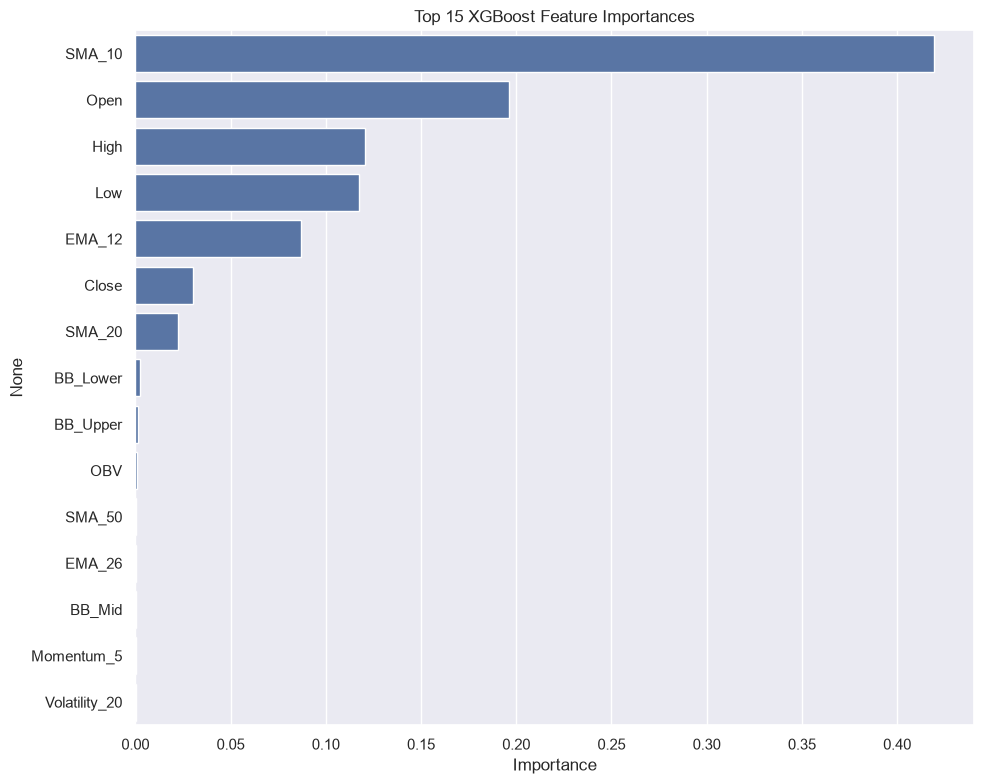

In [9]:
# 5.3 XGBoost Feature Importance
importances = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=importances.values[:15], y=importances.index[:15])
plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 6. Model 2: LSTM (PyTorch)

### 6.1 Sequence Dataset Construction

The LSTM consumes sequences of `LOOKBACK_WINDOW` consecutive days of (scaled)
feature vectors to predict the next day's closing price.

In [10]:
# 6.1 Build Sequences
def build_sequences(features_scaled, targets_scaled, lookback):
    X_seq, y_seq = [], []
    for i in range(lookback, len(features_scaled)):
        X_seq.append(features_scaled[i - lookback:i])
        y_seq.append(targets_scaled[i])
    return np.array(X_seq), np.array(y_seq)

# To build test sequences that include lookback context, combine the tail of the
# training set with the test set before windowing.
combined_features_scaled = np.vstack([X_train_scaled[-LOOKBACK_WINDOW:], X_test_scaled])
combined_targets_scaled = np.concatenate([y_train_scaled[-LOOKBACK_WINDOW:], y_test_scaled])

X_train_seq, y_train_seq = build_sequences(X_train_scaled, y_train_scaled, LOOKBACK_WINDOW)
X_test_seq, y_test_seq = build_sequences(combined_features_scaled, combined_targets_scaled, LOOKBACK_WINDOW)

print("X_train_seq:", X_train_seq.shape, " y_train_seq:", y_train_seq.shape)
print("X_test_seq: ", X_test_seq.shape, " y_test_seq: ", y_test_seq.shape)

assert len(X_test_seq) == len(X_test), "Test sequence length must match test set length"

X_train_seq: (2016, 30, 27)  y_train_seq: (2016,)
X_test_seq:  (512, 30, 27)  y_test_seq:  (512,)


In [11]:
# 6.2 PyTorch Dataset / DataLoader
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = SequenceDataset(X_train_seq, y_train_seq)
test_dataset = SequenceDataset(X_test_seq, y_test_seq)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [12]:
# 6.3 LSTM Model Definition
class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        return self.fc(last_hidden).squeeze(-1)

### 6.4 Hyperparameter Tuning

A small grid search over hidden size and learning rate is performed using a
time-based validation split of the training sequences (last 15%).

In [13]:
# 6.4 LSTM Hyperparameter Tuning
val_seq_split = int(len(X_train_seq) * 0.85)
X_tr_seq, X_val_seq = X_train_seq[:val_seq_split], X_train_seq[val_seq_split:]
y_tr_seq, y_val_seq = y_train_seq[:val_seq_split], y_train_seq[val_seq_split:]

tr_dataset = SequenceDataset(X_tr_seq, y_tr_seq)
val_dataset = SequenceDataset(X_val_seq, y_val_seq)

tr_loader = DataLoader(tr_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

lstm_param_grid = {
    "hidden_size": [32, 64],
    "lr": [0.001, 0.005],
}

EPOCHS_TUNE = 10
input_size = X_train_seq.shape[2]

best_val_loss = np.inf
best_lstm_params = None

for params in ParameterGrid(lstm_param_grid):
    torch.manual_seed(SEED)
    model = LSTMForecaster(input_size=input_size, hidden_size=params["hidden_size"]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"])
    criterion = nn.MSELoss()

    for epoch in range(EPOCHS_TUNE):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()

    model.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred = model(xb)
            val_losses.append(criterion(pred, yb).item())
    avg_val_loss = np.mean(val_losses)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_lstm_params = params

print("Best LSTM params:", best_lstm_params)
print(f"Best validation loss: {best_val_loss:.5f}")

Best LSTM params: {'hidden_size': 32, 'lr': 0.001}
Best validation loss: 0.15986


Epoch 1/30 - Train Loss: 0.55327
Epoch 5/30 - Train Loss: 0.04375
Epoch 10/30 - Train Loss: 0.01004
Epoch 15/30 - Train Loss: 0.01165
Epoch 20/30 - Train Loss: 0.03791
Epoch 25/30 - Train Loss: 0.04130
Epoch 30/30 - Train Loss: 0.00766


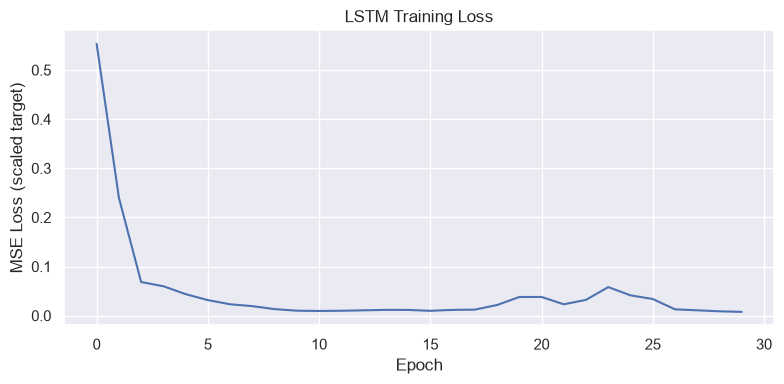

In [14]:
# 6.5 Train Final LSTM Model on Full Training Sequences
EPOCHS_FINAL = 30

torch.manual_seed(SEED)
lstm_model = LSTMForecaster(input_size=input_size, hidden_size=best_lstm_params["hidden_size"]).to(DEVICE)
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=best_lstm_params["lr"])
criterion = nn.MSELoss()

train_loss_history = []

for epoch in range(EPOCHS_FINAL):
    lstm_model.train()
    epoch_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        pred = lstm_model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())
    avg_loss = np.mean(epoch_losses)
    train_loss_history.append(avg_loss)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{EPOCHS_FINAL} - Train Loss: {avg_loss:.5f}")

plt.figure(figsize=(8, 4))
plt.plot(train_loss_history)
plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (scaled target)")
plt.tight_layout()
plt.show()

In [15]:
# 6.6 LSTM Predictions and Evaluation
lstm_model.eval()
all_preds = []
with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(DEVICE)
        pred = lstm_model(xb)
        all_preds.append(pred.cpu().numpy())

lstm_pred_scaled = np.concatenate(all_preds)
lstm_pred = target_scaler.inverse_transform(lstm_pred_scaled.reshape(-1, 1)).flatten()

lstm_results = evaluate_model("LSTM", y_test.reset_index(drop=True),
                                lstm_pred, close_test.reset_index(drop=True))

--- LSTM ---
RMSE:                30.5710
MAE:                 22.8412
Directional Accuracy: 48.44%
Sharpe Ratio:        1.4320



## 7. Model Comparison

In [16]:
# 7. Compare Models
comparison_df = pd.DataFrame([xgb_results, lstm_results])
comparison_df.to_csv(MODEL_COMPARISON_PATH, index=False)
comparison_df

,Model,RMSE,MAE,Directional_Accuracy,Sharpe_Ratio
0,XGBoost,31.354480,21.637238,47.851562,1.255765
1,LSTM,30.571048,22.841190,48.437500,1.431966


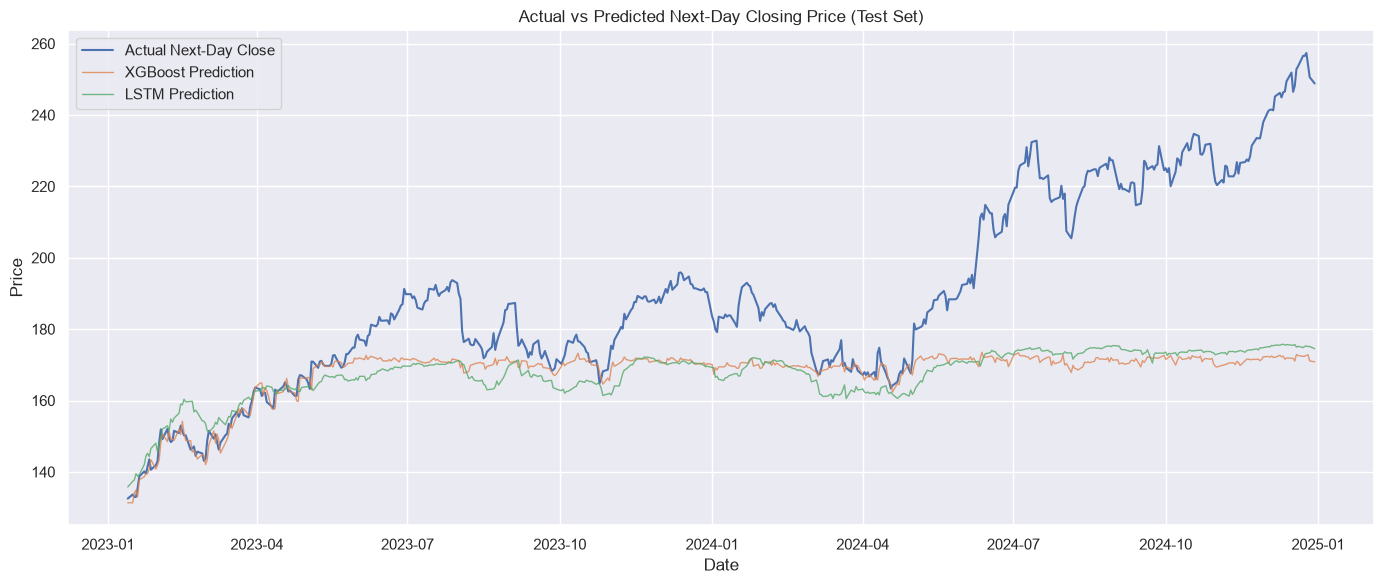

In [17]:
# 7.1 Visualization: Actual vs Predicted (Test Set)
plt.figure(figsize=(14, 6))
plt.plot(dates_test, y_test.values, label="Actual Next-Day Close", linewidth=1.5)
plt.plot(dates_test, xgb_pred, label="XGBoost Prediction", linewidth=1, alpha=0.8)
plt.plot(dates_test, lstm_pred, label="LSTM Prediction", linewidth=1, alpha=0.8)
plt.title("Actual vs Predicted Next-Day Closing Price (Test Set)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()

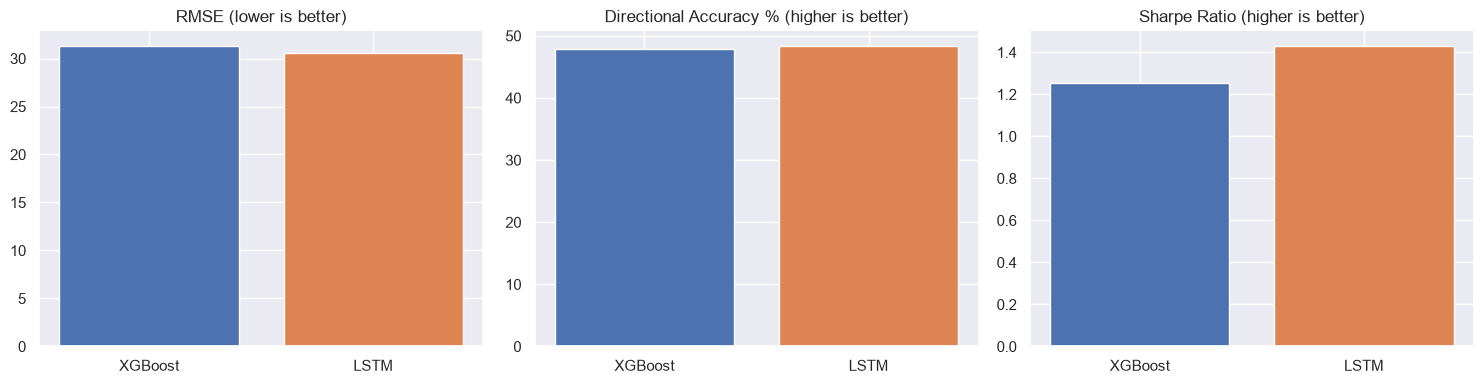

In [18]:
# 7.2 Visualization: Metric Comparison Bar Chart
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(comparison_df["Model"], comparison_df["RMSE"], color=["#4C72B0", "#DD8452"])
axes[0].set_title("RMSE (lower is better)")

axes[1].bar(comparison_df["Model"], comparison_df["Directional_Accuracy"], color=["#4C72B0", "#DD8452"])
axes[1].set_title("Directional Accuracy % (higher is better)")

axes[2].bar(comparison_df["Model"], comparison_df["Sharpe_Ratio"], color=["#4C72B0", "#DD8452"])
axes[2].set_title("Sharpe Ratio (higher is better)")

plt.tight_layout()
plt.show()

## 8. Export Results for Notebook 3

The following artifacts are exported for use by the RAG + Agent pipeline
(Notebook 3):

1. **`results/forecast_predictions.csv`** — date-indexed table of actual close,
   actual next-day close, and both models' predictions for the test period.
2. **`results/model_comparison.csv`** — RMSE, MAE, Directional Accuracy, and
   Sharpe Ratio for both models.
3. **`results/forecast_summary.json`** — a single JSON object summarizing the
   **most recent forecast** (latest available prediction), which Agent 1
   (Quantitative Analyst) in Notebook 3 will consume directly.

In [19]:
# 8.1 Export Predictions Table
predictions_df = pd.DataFrame({
    "Date": dates_test,
    "Actual_Close": close_test.values,
    "Actual_Next_Close": y_test.values,
    "XGBoost_Pred_Next_Close": xgb_pred,
    "LSTM_Pred_Next_Close": lstm_pred,
})
predictions_df.set_index("Date", inplace=True)
predictions_df.to_csv(PREDICTIONS_PATH)

print(f"Predictions exported to {PREDICTIONS_PATH}")
predictions_df.tail()

Predictions exported to results\forecast_predictions.csv


,Actual_Close,Actual_Next_Close,XGBoost_Pred_Next_Close,LSTM_Pred_Next_Close
Date,,,,
2024-12-24,256.560822,256.560822,172.416168,175.168793
2024-12-25,256.560822,257.375580,172.633606,175.257721
2024-12-26,257.375580,253.967392,172.783554,175.117584
2024-12-27,253.967392,250.598923,171.104889,175.135254
2024-12-30,250.598923,248.830215,170.835876,174.526031


In [20]:
# 8.2 Export Forecast Summary (for Agent 1 in Notebook 3)
import json

# Choose the model with the lower test RMSE as the "primary" model
primary_model_row = comparison_df.loc[comparison_df["RMSE"].idxmin()]
primary_model_name = primary_model_row["Model"]
primary_pred_col = "XGBoost_Pred_Next_Close" if primary_model_name == "XGBoost" else "LSTM_Pred_Next_Close"

latest_row = predictions_df.iloc[-1]
last_close = float(latest_row["Actual_Close"])
predicted_next_close = float(latest_row[primary_pred_col])
predicted_change_pct = (predicted_next_close - last_close) / last_close * 100
predicted_direction = "UP" if predicted_next_close > last_close else "DOWN"

forecast_summary = {
    "ticker": "AAPL",
    "as_of_date": str(predictions_df.index[-1].date()),
    "last_close": round(last_close, 4),
    "primary_model": primary_model_name,
    "predicted_next_close": round(predicted_next_close, 4),
    "predicted_change_pct": round(predicted_change_pct, 4),
    "predicted_direction": predicted_direction,
    "recent_volatility_20d": round(float(df["Volatility_20"].iloc[-1]), 6),
    "recent_rsi_14": round(float(df["RSI_14"].iloc[-1]), 2),
    "model_metrics": comparison_df.set_index("Model").to_dict(orient="index"),
}

with open(FORECAST_SUMMARY_PATH, "w") as f:
    json.dump(forecast_summary, f, indent=2)

print(f"Forecast summary exported to {FORECAST_SUMMARY_PATH}")
print(json.dumps(forecast_summary, indent=2))

Forecast summary exported to results\forecast_summary.json
{
  "ticker": "AAPL",
  "as_of_date": "2024-12-30",
  "last_close": 250.5989,
  "primary_model": "LSTM",
  "predicted_next_close": 174.526,
  "predicted_change_pct": -30.3564,
  "predicted_direction": "DOWN",
  "recent_volatility_20d": 0.010169,
  "recent_rsi_14": 57.03,
  "model_metrics": {
    "XGBoost": {
      "RMSE": 31.35448013655998,
      "MAE": 21.637238293886185,
      "Directional_Accuracy": 47.8515625,
      "Sharpe_Ratio": 1.2557648666096417
    },
    "LSTM": {
      "RMSE": 30.57104758507147,
      "MAE": 22.84118950366974,
      "Directional_Accuracy": 48.4375,
      "Sharpe_Ratio": 1.4319656251212634
    }
  }
}


## 9. Summary

- Loaded the processed feature dataset from Notebook 1.
- Performed a time-based 80/20 train-test split.
- Tuned and trained an **XGBoost** regressor via grid search.
- Tuned and trained an **LSTM** network (PyTorch) using 30-day input sequences.
- Evaluated both models on RMSE, MAE, Directional Accuracy, and Sharpe Ratio,
  saved to `results/model_comparison.csv`.
- Exported test-period predictions to `results/forecast_predictions.csv`.
- Exported a single most-recent forecast summary to `results/forecast_summary.json`
  for direct consumption by **Agent 1 (Quantitative Analyst)** in Notebook 3.
